In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
data = pd.read_csv(
    "../datasets/processed/day14_financial_ratios_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset loaded successfully!
Shape: (110, 19)
  company ticker  year  year_end_price  dividend_per_share  dividend_yield  \
0   Apple   AAPL  2015       26.315001              0.5075            1.93   
1   Apple   AAPL  2016       28.955000              0.5575            1.93   
2   Apple   AAPL  2017       42.307499              0.6150            1.45   
3   Apple   AAPL  2018       39.435001              0.7050            1.79   
4   Apple   AAPL  2019       73.412498              0.7600            1.04   

   dividend_growth dividend_growth_category  annual_stock_return  \
0              NaN               First Year                  NaN   
1             9.85                Increased                10.03   
2            10.31                Increased                46.11   
3            14.63                Increased                -6.79   
4             7.80                Increased                86.16   

  return_category  total_return  return_volatility  average_return  \
0     

In [3]:
print("ALL COLUMNS:")

for i, col in enumerate(data.columns):
    print(i, col)

ALL COLUMNS:
0 company
1 ticker
2 year
3 year_end_price
4 dividend_per_share
5 dividend_yield
6 dividend_growth
7 dividend_growth_category
8 annual_stock_return
9 return_category
10 total_return
11 return_volatility
12 average_return
13 dividend_consistency
14 revenue
15 net_income
16 total_assets
17 profit_margin
18 roa


In [4]:
required_columns = [
    "ticker",
    "year",
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "profit_margin",
    "roa",
    "total_return"
]

for col in required_columns:
    print(col, "->", col in data.columns)

ticker -> True
year -> True
dividend_yield -> True
dividend_growth -> True
dividend_consistency -> True
profit_margin -> True
roa -> True
total_return -> True


In [5]:
agency_data = data[
    [
        "ticker",
        "year",
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "profit_margin",
        "roa",
        "total_return"
    ]
].copy()

print("Agency Cost dataset shape:", agency_data.shape)
print(agency_data.head())

Agency Cost dataset shape: (110, 8)
  ticker  year  dividend_yield  dividend_growth  dividend_consistency  \
0   AAPL  2015            1.93              NaN                 90.91   
1   AAPL  2016            1.93             9.85                 90.91   
2   AAPL  2017            1.45            10.31                 90.91   
3   AAPL  2018            1.79            14.63                 90.91   
4   AAPL  2019            1.04             7.80                 90.91   

   profit_margin  roa  total_return  
0            NaN  NaN           NaN  
1            NaN  NaN         11.96  
2            NaN  NaN         47.56  
3            NaN  NaN         -5.00  
4            NaN  NaN         87.20  


In [6]:
print("Missing values:")
print(agency_data.isnull().sum())

Missing values:
ticker                   0
year                     0
dividend_yield           0
dividend_growth         10
dividend_consistency     0
profit_margin           73
roa                     73
total_return            10
dtype: int64


In [7]:
analysis_data = agency_data.dropna(
    subset=[
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "profit_margin",
        "roa",
        "total_return"
    ]
).copy()

print("Complete analysis rows:", analysis_data.shape)

Complete analysis rows: (37, 8)


In [8]:
correlation_columns = [
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "profit_margin",
    "roa",
    "total_return"
]

correlation_matrix = analysis_data[
    correlation_columns
].corr()

print(correlation_matrix.round(4))

                      dividend_yield  dividend_growth  dividend_consistency  \
dividend_yield                1.0000          -0.5660                   NaN   
dividend_growth              -0.5660           1.0000                   NaN   
dividend_consistency             NaN              NaN                   NaN   
profit_margin                -0.3638           0.2674                   NaN   
roa                          -0.6638           0.1319                   NaN   
total_return                 -0.3221           0.1129                   NaN   

                      profit_margin     roa  total_return  
dividend_yield              -0.3638 -0.6638       -0.3221  
dividend_growth              0.2674  0.1319        0.1129  
dividend_consistency            NaN     NaN           NaN  
profit_margin                1.0000  0.6543       -0.0405  
roa                          0.6543  1.0000        0.1066  
total_return                -0.0405  0.1066        1.0000  


In [9]:
yield_profit_corr = analysis_data[
    ["dividend_yield", "profit_margin"]
].corr().iloc[0, 1]

yield_roa_corr = analysis_data[
    ["dividend_yield", "roa"]
].corr().iloc[0, 1]

yield_return_corr = analysis_data[
    ["dividend_yield", "total_return"]
].corr().iloc[0, 1]

growth_profit_corr = analysis_data[
    ["dividend_growth", "profit_margin"]
].corr().iloc[0, 1]

growth_roa_corr = analysis_data[
    ["dividend_growth", "roa"]
].corr().iloc[0, 1]

print("Dividend Yield vs Profit Margin:",
      round(yield_profit_corr, 4))

print("Dividend Yield vs ROA:",
      round(yield_roa_corr, 4))

print("Dividend Yield vs Total Return:",
      round(yield_return_corr, 4))

print("Dividend Growth vs Profit Margin:",
      round(growth_profit_corr, 4))

print("Dividend Growth vs ROA:",
      round(growth_roa_corr, 4))

Dividend Yield vs Profit Margin: -0.3638
Dividend Yield vs ROA: -0.6638
Dividend Yield vs Total Return: -0.3221
Dividend Growth vs Profit Margin: 0.2674
Dividend Growth vs ROA: 0.1319


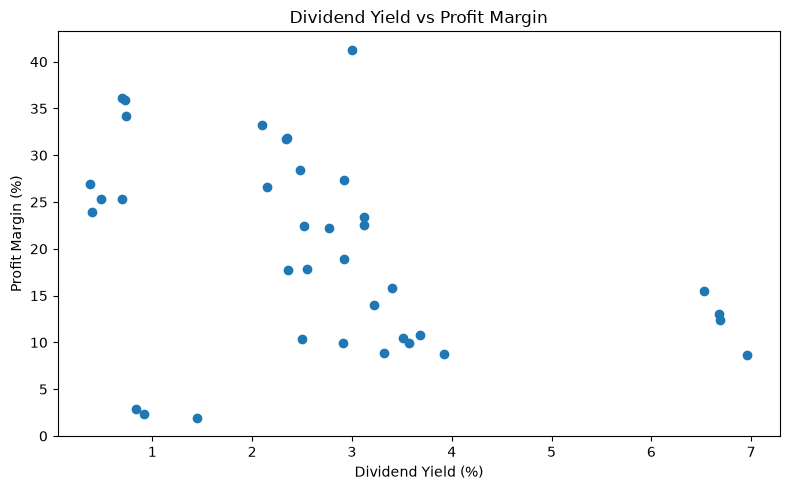

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["profit_margin"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Profit Margin (%)")
plt.title("Dividend Yield vs Profit Margin")

plt.tight_layout()
plt.show()

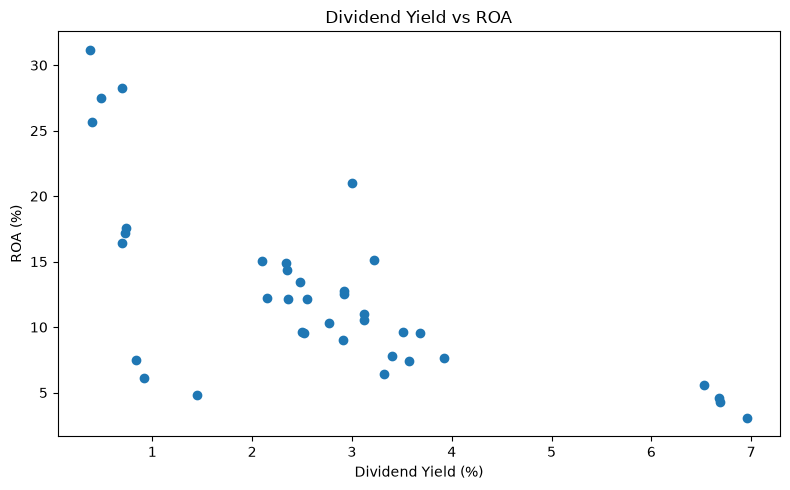

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["roa"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("ROA (%)")
plt.title("Dividend Yield vs ROA")

plt.tight_layout()
plt.show()

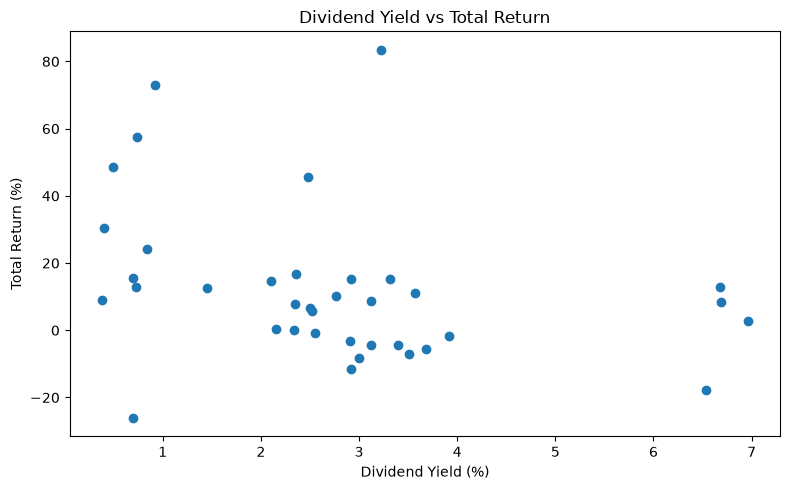

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Yield vs Total Return")

plt.tight_layout()
plt.show()

In [13]:
agency_results = pd.DataFrame({
    "Relationship": [
        "Dividend Yield vs Profit Margin",
        "Dividend Yield vs ROA",
        "Dividend Yield vs Total Return",
        "Dividend Growth vs Profit Margin",
        "Dividend Growth vs ROA"
    ],
    "Correlation": [
        yield_profit_corr,
        yield_roa_corr,
        yield_return_corr,
        growth_profit_corr,
        growth_roa_corr
    ]
})

agency_results["Absolute_Correlation"] = (
    agency_results["Correlation"].abs()
)

print(agency_results.round(4))

                       Relationship  Correlation  Absolute_Correlation
0   Dividend Yield vs Profit Margin      -0.3638                0.3638
1             Dividend Yield vs ROA      -0.6638                0.6638
2    Dividend Yield vs Total Return      -0.3221                0.3221
3  Dividend Growth vs Profit Margin       0.2674                0.2674
4            Dividend Growth vs ROA       0.1319                0.1319


In [14]:
agency_results.to_csv(
    "../datasets/processed/day23_agency_results.csv",
    index=False
)

print("Day 23 Agency Cost results saved successfully!")

Day 23 Agency Cost results saved successfully!
